# 📘 Curs: Gradient Boosting & XGBoost

În acest notebook vom:
- Antrena două modele: `GradientBoostingClassifier` (sklearn) și `XGBClassifier` (xgboost)
- Face tuning cu `GridSearchCV`
- Explora concepte avansate din XGBoost și vom avea exerciții practice.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Încărcăm dataset-ul diabetes
DATA_URL = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(DATA_URL)
print("Dimensiunea datelor:", df.shape)
df.head()

# Împărțim în train/test
X = df.drop(columns=['Outcome'])
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Dimensiunea datelor: (768, 9)
(614, 8) (154, 8) (614,) (154,)


### Random Forest

In [ ]:
# RandomForest classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


accuracy_score(y_test, rf_model.predict(X_test))

0.7597402597402597

## ✅ GradientBoostingClassifier
Vom începe cu modelul din sklearn - GradientBoostClassifier


*   n_estimators = 100
*   learning_rate = 0.1
*   max_depth = 3
*   random_state = 42








In [ ]:
# TODO - Construiește un model de GradientBoostClassifier pentru datele de mai sus

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Antrenăm modelul GradientBoosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

# Evaluăm
print("Accuracy GradientBoosting:", accuracy_score(y_test, gb_model.predict(X_test)))


Accuracy GradientBoosting: 0.7532467532467533


In [ ]:
# TODO - Verifică dacă există o combinație mai bună, folosind GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3],
    "min_samples_leaf": [1, 3, 5],
    "subsample": [0.8, 1.0],
}

grid_search = GridSearchCV(gb_model, param_grid, cv=5, scoring='accuracy', verbose=3)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=0.8;, score=0.756 total time=   0.3s
[CV 2/5] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=0.8;, score=0.813 total time=   0.3s
[CV 3/5] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=0.8;, score=0.732 total time=   0.3s
[CV 4/5] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=0.8;, score=0.756 total time=   0.3s
[CV 5/5] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=0.8;, score=0.803 total time=   0.3s
[CV 1/5] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=1.0;, score=0.740 total time=   0.3s
[CV 2/5] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=1.0;, score=0.821 total time=   0.3s
[CV 3/5] END learnin

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [2, 3],
                         'min_samples_leaf': [1, 3, 5],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=3)

In [ ]:
# Best estimator din GridSearch

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_estimator_)

Best params: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 100, 'subsample': 0.8}
Best CV score: GradientBoostingClassifier(learning_rate=0.05, max_depth=2, min_samples_leaf=5,
                           random_state=42, subsample=0.8)


In [ ]:
best_gb_model = grid_search.best_estimator_
print("Test - Accuracy GradientBoosting:", accuracy_score(y_test, best_xg_model.predict(X_test)))
print("Train - Accuracy GradientBoosting:", accuracy_score(y_train, best_xg_model.predict(X_train)))

Test - Accuracy GradientBoosting: 0.7467532467532467
Train - Accuracy GradientBoosting: 0.8273615635179153


## ✅ XGBClassifier
Diferență: XGBoost are parametri suplimentari (subsample, colsample_bytree, reg_lambda, reg_alpha, gamma) de care vă puteți folosi.

**Hint -** XGBClassifier **NU** face parte din librăria sklearn.

Scop - să construim modelul XGBoost și să îi găsim parametrizarea potrivită

In [ ]:
# TODO - Construiește un model de XGBClassifier

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)

xgb_model.fit(X_train, y_train)
print("Accuracy XGBoost:", accuracy_score(y_test, xgb_model.predict(X_test)))


Accuracy XGBoost: 0.7337662337662337


## ✅ GridSearchCV pentru XGBoost
Care sunt parametrii mai importanți?
- subsample
- colsample_bytree
- gamma

*   subsample - procentul de *observații* folosite pentru fiecare arbore
    *   dacă pui subsample=0.8, fiecare arbore vede doar 80% din date (reduce overfitting)
Tipic 0.6-0.8
*   colsample_bytree - procentul de *features* folosite pentru fiecare arbore
    *   dacă pui colsample_bytree=0.8, arborele vede doar 80% din features (regularizare)
Tipic 0.5-1.0
*   gamma - cât trebuie să fie minimul intern ca să fie acceptat un split
    *   arbitrar - depinde de dataset, gradient etc

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1, 2],
    'reg_alpha': [0, 0.1]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, verbose=3)

grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


Fitting 5 folds for each of 128 candidates, totalling 640 fits
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8;, score=0.707 total time=   0.1s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8;, score=0.699 total time=   0.0s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8;, score=0.691 total time=   0.2s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8;, score=0.683 total time=   0.0s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8;, score=0.689 total time=   0.0s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0;, score=0.699 to

In [ ]:
best_xgb = grid_search.best_estimator_

print("Test - Accuracy XGBoosting:", accuracy_score(y_test, best_xgb.predict(X_test)))
print("Train - Accuracy XGBoosting:", accuracy_score(y_train, best_xgb.predict(X_train)))

Test - Accuracy XGBoosting: 0.7727272727272727
Train - Accuracy XGBoosting: 0.8436482084690554


# 🏋️ Exerciții

### 1. Regularization (L1, L2)
- **Ce este?** L1 (`reg_alpha`) și L2 (`reg_lambda`) penalizează complexitatea modelului.
- **Exercițiu:** Rulează XGBoost cu `reg_alpha=0.5` și `reg_lambda=2` (vs același model, dar fără ele). Compară acuratețea.

### 2. A unique Regression Tree model
- **Ce este?** XGBoost folosește arbori de regresie chiar și pentru clasificare.
- **Exercițiu:** Folosește metoda plot_tree din xgboost să îi vezi forma (cu rankdir="LR", se vede mai bine).

### 3. Approximate Greedy Algorithm
- **Ce este?** Folosește histograme pentru split-uri.
- **Exercițiu:** Setează `tree_method='approx'` și compară timpul cu `tree_method='exact'`.
- **Hint:** Ca să vezi timpul exact poți folosi time.time() (import time)


### 1. Regularization

L1 penalizează MAI PUTERNIC decât L2 — dar în mod diferit.

L2 împinge greutățile spre zero,


L1 le taie complet la zero (sparsity).

In [ ]:
model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, model.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, model.predict(X_test)))

Train accuracy: 0.9185667752442996
Test accuracy: 0.7597402597402597


In [ ]:
model_reg = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    reg_alpha=0.5,   # L1
    reg_lambda=2,    # L2
    random_state=42
)

model_reg.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, model_reg.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, model_reg.predict(X_test)))

Train accuracy: 0.9006514657980456
Test accuracy: 0.7402597402597403


### 2. A unique regression tree model

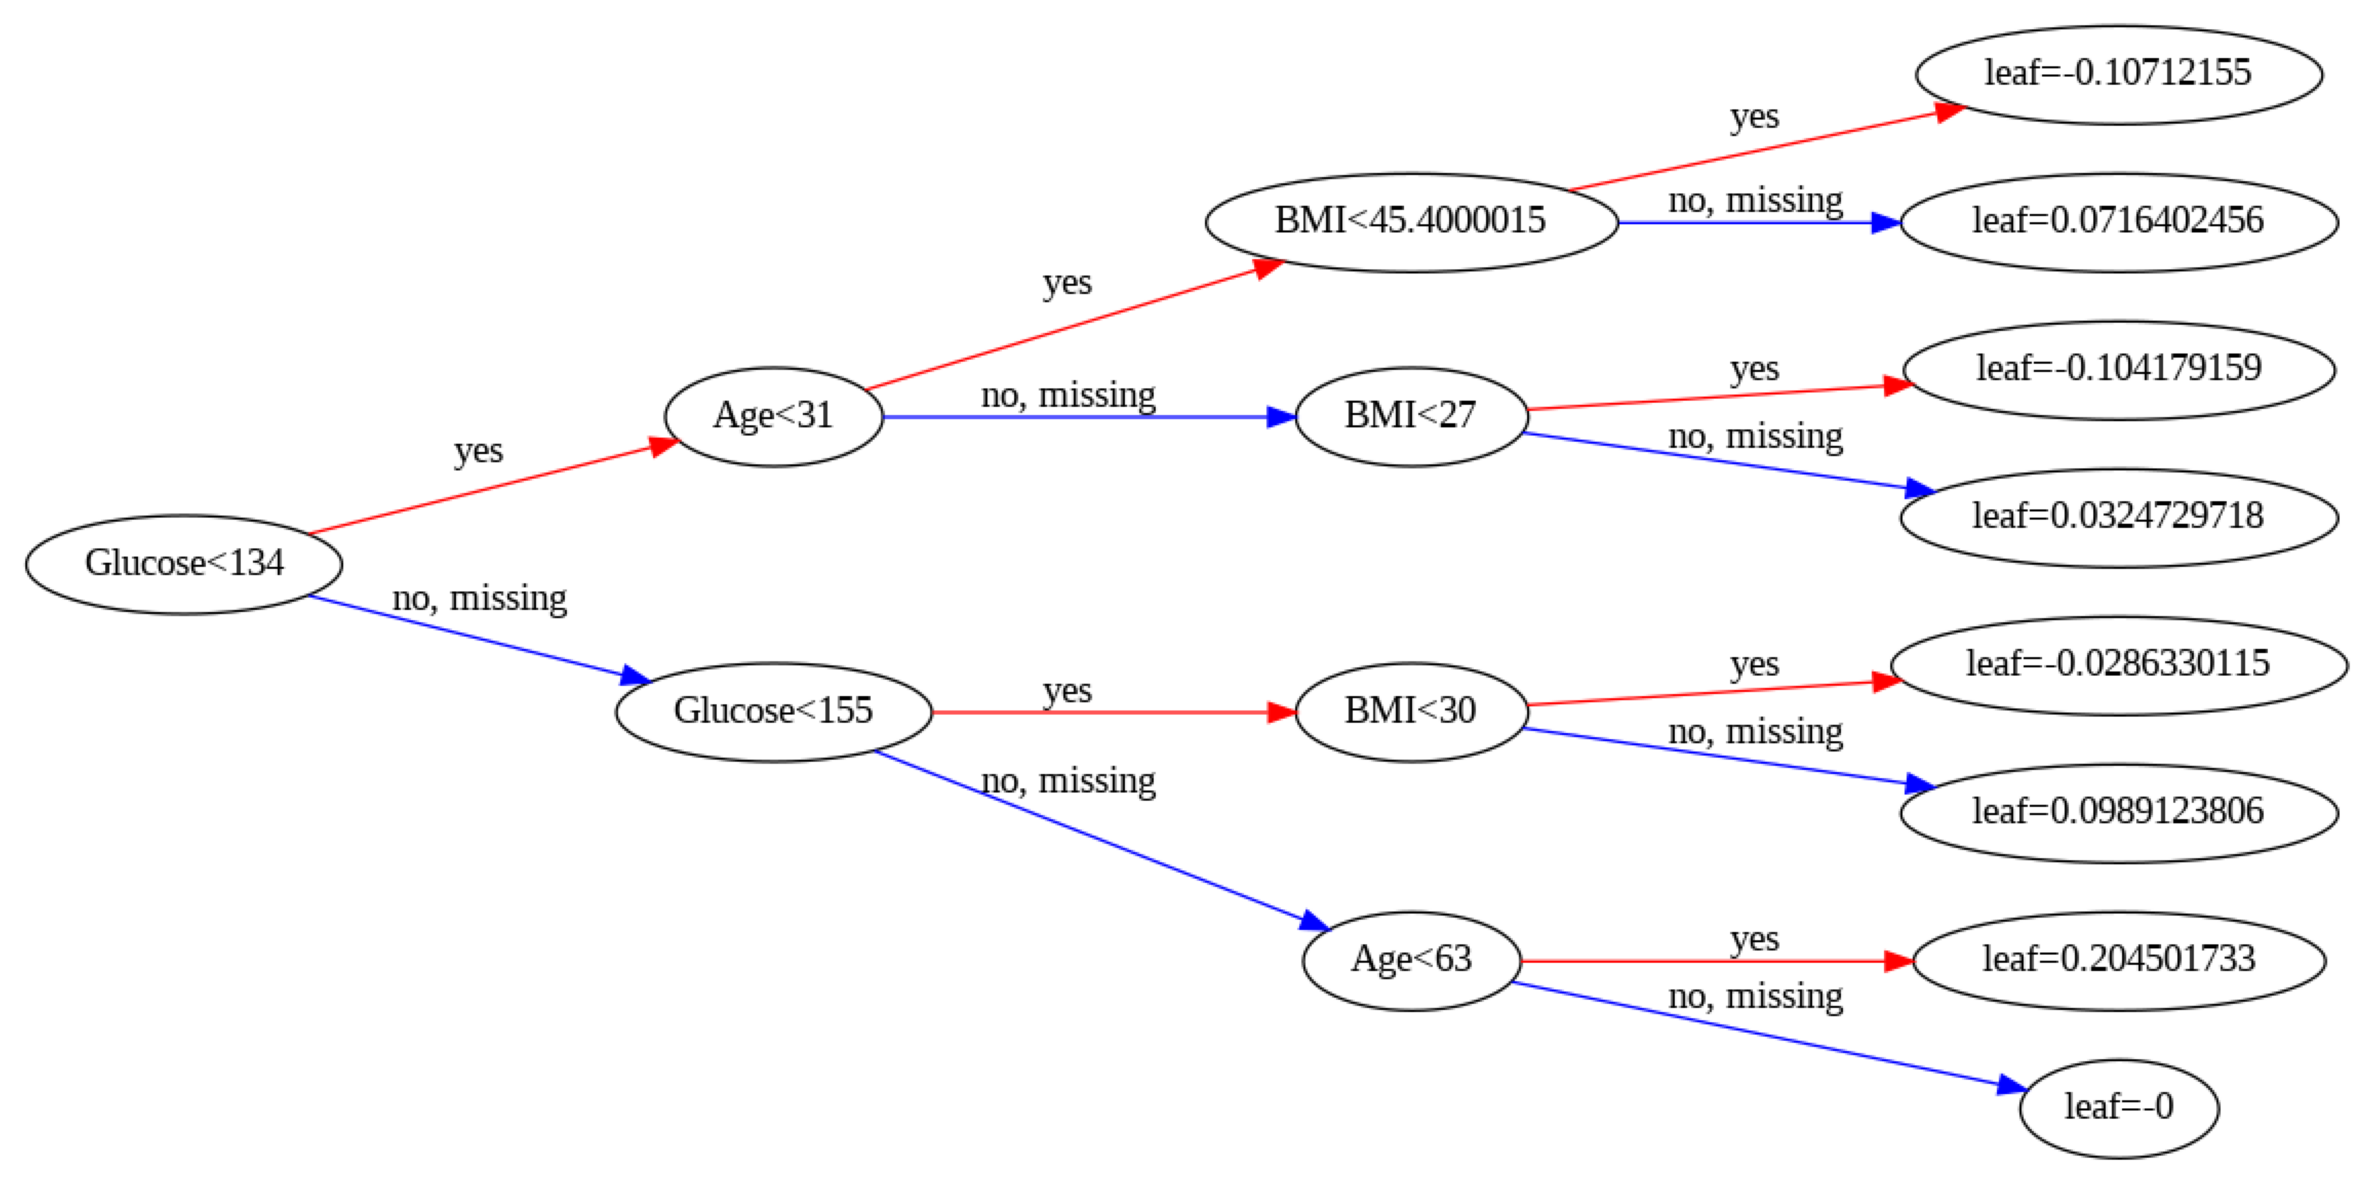

In [ ]:
from xgboost import plot_tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(30, 8))  # mare și lat
plot_tree(
    model_reg,
    rankdir="LR",   # left→right, nu top→bottom
    ax=ax
)
plt.tight_layout()
plt.show()


### 3. Approximate Greedy Alghoritm

Pe diabetes diferența de timp va fi mică

Pe alte seturi de date, approx e clar mai rapid

In [ ]:
import time

def run(method):
    m = XGBClassifier(tree_method=method, eval_metric="logloss")
    time_start = time.time()
    m.fit(X_train, y_train)
    t = time.time() - time_start
    print(method, "time:", round(t,3), "acc:", accuracy_score(y_test, m.predict(X_test)))

run("exact")
run("approx")


exact time: 1.525 acc: 0.7272727272727273
approx time: 0.33 acc: 0.7532467532467533
